In [1]:
import pdfplumber
import pandas as pd
import re
import os
import matplotlib.pyplot as plt

In [2]:
def clean_val(val):
    if val is None or val == '-': return None
    # Fix the unicode minus sign (−) and the ± symbol
    clean_str = str(val).split('±')[0].replace('−', '-').replace(" ", "")
    try:
        return float(clean_str)
    except:
        return None


In [3]:
folder_path = r"C:\pea\code\parameter_guesser"
exclude = ['.ipynb_checkpoints','.venv','circuits']
folders = [f.name for f in os.scandir(folder_path) 
           if f.is_dir() and not any(x in f.name for x in exclude)]
print(folders)

['8HQ', 'BTA', 'Lcystine', 'MBT', 'Molybdate', 'NaCl', 'NaVO3']


In [4]:
all_data = []
for compound in folders:
    file_path = rf"C:\pea\code\parameter_guesser\{compound}\good_data"
    # Loop through your files
    for filename in os.listdir(file_path):
        if filename.endswith(".pdf"):
            path = os.path.join(file_path, filename)
            with pdfplumber.open(path) as pdf:
                table = pdf.pages[0].extract_table({"vertical_strategy": "lines", "horizontal_strategy": "lines"})
                if not table: continue
                
                df_temp = pd.DataFrame(table[1:], columns=table[0])

                filename_hours = [int(h) for h in re.findall(r'_(\d+)H(?=_|$)', filename)]
                filename_circuit = re.findall(r'(\d+)RC', filename)
                #print(filename_circuit)
                if not filename_hours: continue
                
                for _, row in df_temp.iterrows():
                    element = row['Element']

                    circuit_num = int(filename_circuit[0]) if filename_circuit else 1
    
                    if circuit_num == 2:
                        # Swap R1/R2, n1/n2, Q1/Q2
                        swap_map = {'R1': 'R2', 'R2': 'R1', 'n1': 'n2', 'n2': 'n1', 'Q1': 'Q2', 'Q2': 'Q1','W1': 'W2', 'W2': 'W1'}
                        element = swap_map.get(element, element)
                
                    elif circuit_num == 3:
                        # Swap R1/R3, n1/n3, Q1/Q3
                        swap_map = {'R1': 'R3', 'R3': 'R1', 'n1': 'n3', 'n3': 'n1', 'Q1': 'Q3', 'Q3': 'Q1'}
                        element = swap_map.get(element, element)
        
                    for col in df_temp.columns:
                        col_hour_match = re.search(r'(\d+)H\b', str(col))

                        if col_hour_match:
                            col_hour = int(col_hour_match.group(1))
                            #print(col_hour)
                            if col_hour in filename_hours:
                                val = clean_val(row[col])
                                #print(val)
                                all_data.append({
                                    'compound': compound,
                                    'element': element, 
                                    'hour': col_hour, 
                                    'value': val
                                })



In [5]:
df_master = pd.DataFrame(all_data)

# Pivot to have both Element and Compound as rows, and Hours as columns
df_pivot = df_master.pivot_table(
    index=['element', 'compound'], 
    columns='hour', 
    values='value', 
    aggfunc='first'
)

# Sort columns (hours) numerically
df_pivot = df_pivot.reindex(sorted(df_pivot.columns), axis=1)


In [6]:
df_r1 = df_pivot.xs('n1', level='element')

print("--- R1 Values Across All Compounds ---")
print(df_r1)


--- R1 Values Across All Compounds ---
hour         1      4      8      24     48     72     168
compound                                                  
8HQ        0.904  1.000  1.000  0.984  0.793  0.797  0.752
BTA        0.897  0.886  1.000  0.890  0.830  0.803  0.714
Lcystine   0.910  0.895  0.882  0.861  0.849  0.843  0.833
MBT        0.928  0.917  0.910  0.857  1.000  1.000  0.945
Molybdate  0.909  0.897  0.903  0.909  0.889  0.883  0.793
NaCl       1.000  0.960  0.976  0.803  0.856  0.807  0.751
NaVO3      0.896  0.878  0.868  0.847  0.840  0.840  0.829


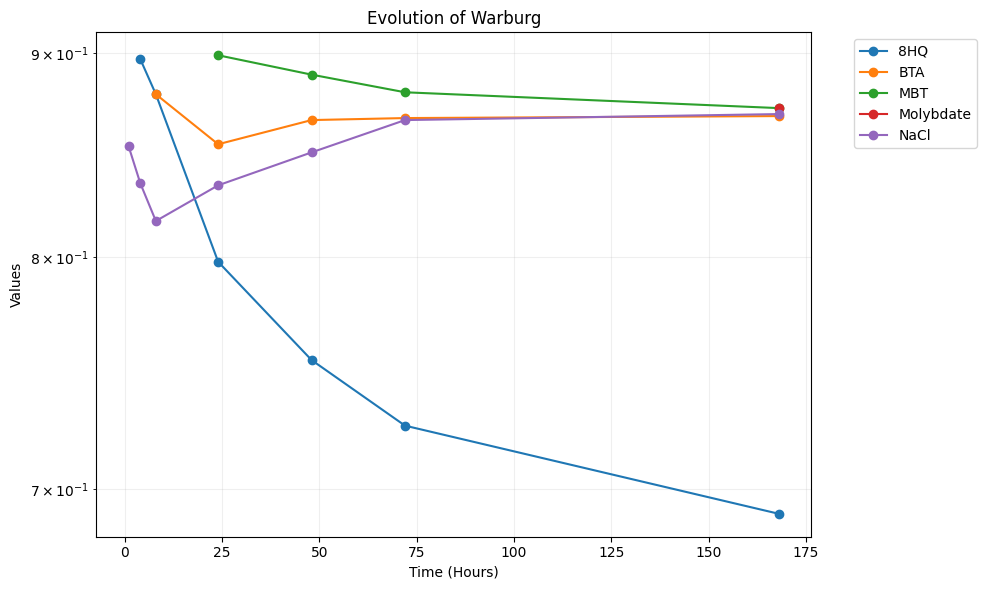

In [30]:
df_r1 = df_pivot.xs('n2', level='element')
plt.figure(figsize=(10, 6))
hours = df_r1.columns.values

for compound in df_r1.index:
    # Use .dropna() if you want the lines to connect across NaN values
    y_values = df_r1.loc[compound].values
    plt.plot(hours, y_values, marker='o', label=compound)

plt.title("Evolution of Warburg")
plt.xlabel("Time (Hours)")
plt.ylabel("Values")
plt.yscale('log')  # Recommended because your values range from 10^-6 to 10^2
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left') # Move legend outside
plt.grid(True, which="both", ls="-", alpha=0.2)
plt.tight_layout()
#plt.savefig('W.png',dpi = 500)
plt.show()
